# Pràctica de Regressió Lineal amb la base de dades "Brain Cancer Data".
## Objectius de la pràctica:
1. Treballar amb  la base de dades Brain Cancer Data.
   * #### Suposarem que és un problema que ens han encarregat resoldre i proporcionarem:
    1. Propietats de les variables observades i com es relacionen amb el temps de supervivència.
    2. Explicació de com les variables observades afecten la variable de supervivència.
    3. Crearem un predictor de temps de supervivència.
3. Aprendre a fer "Exploratory Data Analysis" (EDA),  per entendre la base de dades i el problema a resoldre.
4. Resoldre el problema fent servir una técnica simple i intuitiva, Regressió lineal.
5. **Predir i explicar** el temps de supervivència a partir de les mesures.

# Esquema del procés de treball en Aprenentatge Automàtic.

<img src="procestreballAprenentatgeAutomatic.png" width="700" height="600">

## 1. Descripció del problema:

**Objectiu**

Estudi sobre el temps de supervivència per a pacients amb tumors cerebrals primaris que van rebre tractament amb mètodes de radioteràpia estereotàctica a l'Institut de Càncer Masaryk Memorial Brno (veure [1]). Identificant factors de risc i característiques, i  la seva influència en el temps de supervivència.

**Especificacions**

1. Estudiar composició de la base de dades.
2. Entendre la relació entre les mesures i les dades de supervivència, 
3. Veure la distribució de les variables i com les seves estadistiques poden influir en el temps de supervivència.
4. **Analitzar el predictor resultant**, per entendre com s'explica el temps de supervivència.

**Bibliografia**

* [1]  Selingerova, I., Dolezelova, H., Horova, I., Katina, S., & Zelinka, J. (2016). Survival of patients with primary brain tumors: Comparison of two statistical approaches. PLoS One, 11(2), e0148733.
* https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4749663/


### <font color="blue"><b>1.1. Variables de la base de dades</b></font>   

| Variable | Descripció de variable |
|---|---|
| **sex** | Factor amb nivells "Dona" i "Masculi" |
| **diagnosis** | Factor amb nivells "Meningioma", "glioma LG", "glioma HG" i "Altres". 
| **loc** | Factor de localització amb nivells "Infratentorial" i "Supratentorial". 
| **ki** | Índex de Karnofsky. |
| **gtv** | Volum tumoral brut, en centímetres cúbics. |
| **stereo**  | Factor mètode estereotàctic amb nivells "SRS" i "SRT". |
| **status** | Si el pacient encara està viu al final de l'estudi. 0=Sí, 1=No. |
| **time** | Temps de supervivència, en mesos |



### <font color="blue"><b>1.2. Explicació de les variables</b></font> 

#### 1.2.1. Índex de Karnofsky

 <blockquote>
ki: És una eina utilitzada per avaluar l'estat funcional dels pacients amb càncer. Va ser desenvolupat pels doctors Karnofsky i Burchenal l'any 1949. Aquest índex mesura la <b>capacitat del pacient per realitzar les activitats de la vida diària i la seva capacitat de treball</b>. És una eina àmpliament utilitzada en oncologia per avaluar el pronòstic del pacient i la resposta al tractament.
</blockquote>


#### 1.2.1. Variables diagnosi i localitzacio:
 
 |**Diferència entre Meningioma i glioma**  | **Localització: Infratentorial i Supratentorial**  |
 |---|---|
 |<img src="MeningiomaGlioma.gif" alt="Location" width="300" height="300">| <img src="Illu_tentorium.jpg" alt="Location" width="300" height="300"> |

**Radioteràpia Estereotàctica**

**La radioteràpia estereotàctica** és una forma molt precisa de radioteràpia utilitzada per tractar tumors i altres anomalies al cos. Implica l'ús de múltiples feixos de radiació que convergeixen en un objectiu específic, proporcionant una alta dosi de radiació a l'àrea afectada, alhora que es minimitza el dany al teixit saludable circumdant.

Hi ha dos tipus principals de radioteràpia estereotàctica:

1. **Cirurgia radiològica estereotàctica (SRS)**: Normalment s'utilitza per tractar petits tumors al cervell i altres parts del cos. Sovint es completa en una única sessió.
2. **Radioteràpia corporal estereotàctica (SBRT)**: S'utilitza per tractar tumors en el cos, com en els pulmons, fetge, columna vertebral i altres teixits tous. Normalment implica múltiples sessions.

Ambdues metodologies utilitzen tècniques d'imatges avançades per dirigir-se amb precisió al tumor, assegurant un impacte mínim en els teixits saludables.


#### Diferències entre SRS i SRT



| Característica            | SRS (Radiocirurgia estereotàctica)         | SRT (Radioteràpia estereotàctica)         |
|---------------------------|---------------------------------------------|-------------------------------------------|
| **Dosificació**           | Dosi alta en una sola sessió               | Dosi fraccionada en diverses sessions     |
| **Mida de la diana**      | Petites dianes ben definides               | Dianes més grans o de formes irregulars   |
| **Precisió**              | Extremadament alta                        | Alta, però ajustada per la fraccionació   |
| **Durada**                | Un sol dia                                | De dies a setmanes                      |
| **Aplicacions**           | Metàstasis cerebrals, MAV, tumors petits  | Tumors més grans o prop d'estructures crítiques |



## <font color="red"><b>Exercici 1</b></font>
1. Per tal de **clarificar els objectius d'aquesta pràctica**, redactar un paràgraf resumint el tipus de base de dades utilitzada i l'objectiu de la pràctica.
2. Abans d'aplicar mètodes d'Intel.ligència artificial, cal tenir una intuició sobre com influencien les variables observacionals  el resultat. A partir de la descripció de les variables escrigui breument la llista de variables que poden agumentar o disminuir el temps de supervivència. Redactar  una explicació d'una línia per justificar cada cas.

# 2. Regressió Lineal: Una Introducció Intuïtiva

## 2.1. Què és la Regressió Lineal?

La regressió lineal és un mètode estadístic per estimar la relació entre variables mitjançant <u>**una línia recta**</u>. 

**Metàfora:** un procés de "combinar puntuacions relacionades" per predir un resultat.

### 2.1.1. Exemple: **Calcular preu d'una casa**

**Calcular f(x)= preu d'una casa** on **x** és un vector d'observables.

Per predir el preu d'una casa, els factors que influeixen en el preu poden ser:
- Superfície de la casa
- Nombre d'habitacions
- Ubicació
- Antiguitat

La regressió lineal combinr aquests factors de manera ponderada per estimar el preu final.

### 2.1.2.  Formulació Matemàtica

La fórmula  de la regressió lineal és:

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$

On:
- $y$ és la variable que volem predir
- $\beta_0$ és el punt d'intercepció (valor base)
- $\beta_1, \beta_2, ..., \beta_n$ són els coeficients (importància de cada factor)
- $x_1, x_2, ..., x_n$ són els factors/variables
- $\epsilon$ representa l'error del model

### 2.1.3.  Exemple de Combinació de Puntuacions

Pensem en el preu d'una casa:
- $\beta_0$ = 50.000€ (preu base)
- $\beta_1$ = 200€/m² (valor per metre quadrat)
- $\beta_2$ = 10.000€/habitació (valor per habitació)

Si una casa té:
- 100m²
- 3 habitacions

$\text{Preu} = 50.000 + (200 \times 100) + (10.000 \times 3) = 50.000 + 20.000 + 30.000 = 100.000$€

## 3. Definició Formal de la Regressió Lineal.
### <font color="blue"><b>**Veure diagrama dibuixat a la pissarra**</b></font> 
### 3.1. Què és la Regressió Lineal?

La **regressió lineal** és una tècnica estadística utilitzada per modelar la relació entre una variable dependent ($y$) i una o més variables independents ($X_i$). L'objectiu principal de la regressió lineal és ajustar una línia recta que millor representi la relació entre les variables, **minimitzant l'error** (veure eq. 1 mes abaix) entre els valors predits i els valors reals.

- **Fórmula de la Regressió Lineal**:
  $ y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_n X_n + \epsilon $

  On:
  - $y$: Variable dependent (resposta o objectiu).
  - $X_1, X_2, \ldots, X_n$: Variables independents (predictors).
  - $\beta_0$: Intercept o terme constant.
  - $\beta_1, \beta_2, \ldots, \beta_n$: Coeficients que indiquen l'impacte de cada predictor sobre $y$.
  - $\epsilon$: Terme d'error (diferència entre els valors reals i els valors predits).

### 3.2. Com funciona?
La regressió lineal utilitza el mètode dels mínims quadrats per ajustar una línia als punts de dades. Això implica trobar els valors de $\beta_0$ i $\beta_1, \beta_2, \ldots, \beta_n$ que minimitzin la suma dels quadrats de les diferències entre els valors reals ($y$) i els valors predits ($\hat{y}$).

###  Mètode d'Estimació: Mínims Quadrats

Per trobar els millors $\beta$, fem servir el mètode de mínims quadrats:

**(1)** &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\min_{\beta} \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1x_{1i} + \beta_2x_{2i} + ... + \beta_nx_{ni}))^2$

On:
  - $y_i$: Resposta real per les observacions $X_1, X_2, \ldots, X_n$.
    
#### Busquem minimitzar la diferència quadràtica entre els valors predits $ y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_n X_n $ i reals $y_i$.


### <u>Veure Apendix 1 </u> per  Mètode d'Estimació dels coeficients  $\beta_0, \beta_1, \beta_2, \ldots, \beta_n$: per Mínims Quadrats 

# 4. Part pràctica.

* ####  Primer carreguem les llibreries de python 
* ####  Desprès carreguem la base de dades


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np
import os

#### Lectura de la base de dades.

In [2]:
df_DataBase = pd.read_excel('BrainCancer.xlsx')
df_DataBase.drop(columns = ['Unnamed: 0'],inplace = True)
df_DataBase.head()

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30


#### Fem un comptatge de les combinacions de variables **qualitatives**.

In [3]:
df_DataBase[['sex','diagnosis','loc','stereo']].value_counts()

sex     diagnosis   loc             stereo
Female  Meningioma  Supratentorial  SRT       16
Male    HG glioma   Supratentorial  SRT       13
        Meningioma  Supratentorial  SRT       10
Female  HG glioma   Supratentorial  SRT        7
        Meningioma  Infratentorial  SRS        6
                    Supratentorial  SRS        5
Male    LG glioma   Supratentorial  SRT        5
        Meningioma  Supratentorial  SRS        4
Female  Other       Supratentorial  SRT        3
Male    Other       Infratentorial  SRT        3
                                    SRS        3
                    Supratentorial  SRT        2
Female  Other       Infratentorial  SRT        2
        LG glioma   Supratentorial  SRS        2
Male    HG glioma   Infratentorial  SRS        1
        LG glioma   Infratentorial  SRT        1
        Meningioma  Infratentorial  SRT        1
Female  Other       Infratentorial  SRS        1
        Meningioma  Infratentorial  SRT        1
        LG glioma   Suprat

#### Fem un comptatge de les combinacions de variables **quantitatives**.

In [4]:
df_DataBase.describe()

,ki,gtv,status,time
count,88.000000,88.000000,88.000000,88.000000
mean,81.022727,8.660795,0.397727,27.457500
std,10.508866,8.657576,0.492233,20.124412
min,40.000000,0.010000,0.000000,0.070000
25%,80.000000,2.500000,0.000000,10.392500
50%,80.000000,6.510000,0.000000,24.030000
75%,90.000000,12.100000,1.000000,41.597500
max,100.000000,34.640000,1.000000,82.560000


## <font color="red"><b>Exercici 2</b></font>
1. Expliqui breument (dos línies) la informació que proporcionen les instruccions: df_DataBase.describe() i df_DataBase['diagnosis'].value_counts().
2. Hem fet servir l'instrucció: df_DataBase['diagnosis'].value_counts().
*  Qué podeu dir sobre  la seva fiabilitat de les combinacions, per estimar les probabilitats de resultats?

# 4.1. Anàlisi exploratòria de dades (EDA)

## 4.1.1. Estructura del DataFrame.
###   **Metafora:**  un full excel.

Analitzem l'estructura i les dades resum del conjunt de dades per comprendre les seves columnes i els tipus de dades que contenen.

**Recordar** que EDA és important per a  <font color="Blue"><b>l'informe Final i Recomanacions</b></font> que es presenten al final dels estudis.

In [5]:
print('_'*50)
print('* Observar que té estructura excel, amb capcelera amb \n noms de variables i enumeració d"exemples')
print('_'*50)
df_DataBase.head()

__________________________________________________
* Observar que té estructura excel, amb capcelera amb 
 noms de variables i enumeració d"exemples
__________________________________________________


,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30


In [6]:
# Estructura bàsica i tipus de dades
df_DataBase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sex        88 non-null     object 
 1   diagnosis  88 non-null     object 
 2   loc        88 non-null     object 
 3   ki         88 non-null     int64  
 4   gtv        88 non-null     float64
 5   stereo     88 non-null     object 
 6   status     88 non-null     int64  
 7   time       88 non-null     float64
dtypes: float64(2), int64(2), object(4)
memory usage: 5.6+ KB


## <font color="red"><b>Exercici 3</b></font>
1. Si fem servir un mètode per predir el temps basat en una combinació lineal del tipus:
* $ y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_n X_n + \epsilon $

* $ time = \beta_0 + \beta_1 \text{sex} + \beta_2 \text{diagnosis} + \beta_3 \text{loc} + \beta_4 \text{ki} + \beta_5 \text{gtv} + \beta_6 \text{stereo} + \beta_7 \text{status} + \epsilon$

  * Quina transformació s'ha de fer sobre les dades perquè el format sigui acceptable per el software?. Pista:  Dtype: object, es un "string".

## 4.1.2.  Descripció general de les dades.
### Estadístiques resumides de les variables numèriques.

El mètode `df_DataBase.describe()` és una funció  en Python,  dins de la llibreria Pandas, que proporciona un resum estadístic  de les columnes numèriques d'un DataFrame:

* **count:** El nombre de valors no nuls en cada columna.
* **mean:** La mitjana aritmètica dels valors.
* **std:** La desviació estàndard dels valors.
* **min:** El valor mínim.
* **25%:** El percentil 25 (el valor per sota del qual es troba el 25% dels valors).
* **50%:** El percentil 50 (la mediana).
* **75%:** El percentil 75 (el valor per sota del qual es troba el 75% dels valors).
* **max:** El valor màxim.

Aquesta informació  permet obtenir una primera visió general de les dades i **identificar possibles anomalies o tendències**.

In [7]:
# Estadístiques descriptives per a les columnes numèriques
df_DataBase.describe().round(2)

,ki,gtv,status,time
count,88.00,88.00,88.00,88.00
mean,81.02,8.66,0.40,27.46
std,10.51,8.66,0.49,20.12
min,40.00,0.01,0.00,0.07
25%,80.00,2.50,0.00,10.39
50%,80.00,6.51,0.00,24.03
75%,90.00,12.10,1.00,41.60
max,100.00,34.64,1.00,82.56


In [8]:
# Estadístiques descriptives per a les columnes categòriques
df_DataBase.describe(include='object').round(2)


,sex,diagnosis,loc,stereo
count,88,88,88,88
unique,2,4,2,2
top,Female,Meningioma,Supratentorial,SRT
freq,45,43,69,65


## <font color="red"><b>Exercici 4</b></font>
1. Expliqui breument la informació que proporciona l'instrucció df_DataBase.describe(), per els casos gtv i time. Observar que la mitjana aritmètica i mediana (percentil 50%) són diferents, i les desviacions estandard són molt semblants a les mitjanes. Es coherent amb una distribució Gausiana?, Quina distribució estadística coneix que tingui aquesta propietat?

* **Atenció**: aquest apartat servirà per interpretar mes endavant la figura: Box Plot (diagrama en capces).

## 4.1.3. Estudi de la distribució de cada columna
1. *Columnes categòriques*:
Identifiquem els valors únics i la seva freqüència per a cada columna categòrica.
3. *Columnes numèriques*:
Visualitzem la distribució de les columnes numèriques mitjançant histogrames i diagrames de caixa.


In [9]:
# Valors únics i freqüència
for col in ['sex', 'diagnosis', 'loc',  'status']:
    print(f"\nDistribució de valors per {col}: (percentatge)")
    print(df_DataBase[col].value_counts(normalize=True).round(4)*100)



Distribució de valors per sex: (percentatge)
sex
Female    51.14
Male      48.86
Name: proportion, dtype: float64

Distribució de valors per diagnosis: (percentatge)
diagnosis
Meningioma    48.86
HG glioma     25.00
Other         15.91
LG glioma     10.23
Name: proportion, dtype: float64

Distribució de valors per loc: (percentatge)
loc
Supratentorial    78.41
Infratentorial    21.59
Name: proportion, dtype: float64

Distribució de valors per status: (percentatge)
status
0    60.23
1    39.77
Name: proportion, dtype: float64


## <font color="red"><b>Exercici 5</b></font>
1. Expliqueu breument (un paràgraf) quina utilitat creieu que pot tenir l'instrucció anterior. Per exemple, podem veure que homes i dones estan igualment representats. Quina fiabilitat tindràn les observacions amb poques mostres. (una oració)
2. Proposi un clasificador per **status** que necesita una línea de codi i proporciona un $60.23 \%$ d'encerts.

        Recordatori: **status**: Si el pacient encara està viu al final de l'estudi. 0=Sí, 1=No.

## 4.1.4. Histograma (distribució de prob.).
* Nota: fem servir la llibria "seaborn" (https://seaborn.pydata.org/examples/)
* ## Histograma

    * Un histograma és una representació aproximada de la distribució de dades numèriques. Va ser introduït per primera vegada per Karl Pearson. Per construir un histograma, el primer pas és "classificar" l'abast dels valors, és a dir, dividir l'abast complet dels valors en una sèrie d'intervals, i després comptar quants valors cauen en cada interval.
    
    * **Definició formal Histograma:**  $\sum_{i=1}^{n} f(x_i)$
    
    on $ f(x_i) $ és la freqüència d'aparició del valor $ x_i $ en el conjunt de dades.

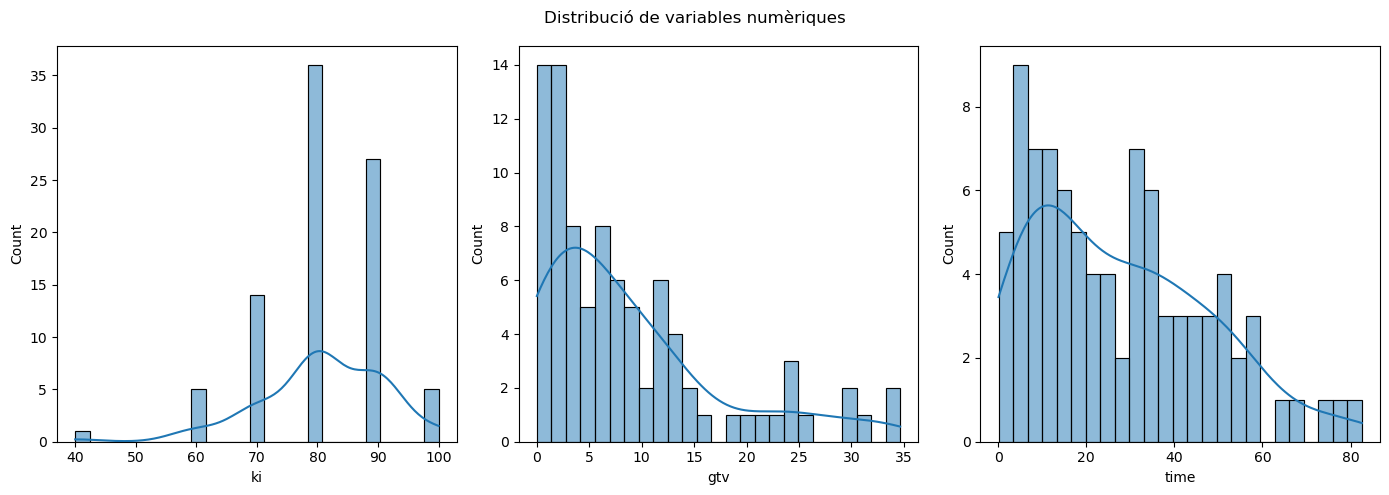

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 5))

for ax, col in zip(axes, ['ki', 'gtv', 'time']):
    sns.histplot(data=df_DataBase, x=col, bins=25, kde=True, ax=ax)

fig.suptitle('Distribució de variables numèriques')
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 6</b></font>
Observeu que els valors numèrics no semblen de cap manera gaussians, no hi ha un valor mig clar, i el concepte de desviació típica no té sentit en aquest cas.
1. Expliqueu amb paraules (tres línies) el que enteneu per valor mitjà, mediana  i desviació estàndard
2. Expliqueu, a partir de la descripció anterior, per què aquests descriptius **no** tenen sentit en les variables: 'ki', 'gtv', 'time'.

*   **Nota**: Una alternativa al  millor és el diagrama de capces a continuació.
*   **Nota**: Per estudiants avançats: fer una ullada a la llibreria seaborn:  (https://seaborn.pydata.org/examples/).

## 4.1.5.  Explicació del diagrama de capces (box plot)

 El box plot, o diagrama de capces, és una eina gràfica utilitzada per representar la distribució d'una variable numèrica en un conjunt de dades. 

Els percentils que es marquen en un diagrama de caixa són:

- El quartil inferior (Q1), que correspon al 25% de la mostra.
- La mediana (Q2), que correspon al 50% de la mostra.
- El quartil superior (Q3), que correspon al 75% de la mostra.
- Mediana: **línia horitzontal verda**  representa la mediana, 50% de la mostra.
- Les linies horizontals superior i inferior representen els valors Q1x1,5 i Q3x1,5. Els punts que es troben fora d'aquest rang s'anomenen punts atípics o outliers.
- Valor mitjà esta representat per un punt vermell.
- Valors extrems (Outliers) representats amb cercles.

* Aquests percentils divideixen la mostra en quatre parts iguals, de manera que el 25% inferior de la mostra es troba per sota del quartil inferior, el 25% superior de la mostra es troba per sobre del quartil superior, i la meitat de la mostra es troba entre el quartil inferior i el quartil superior.



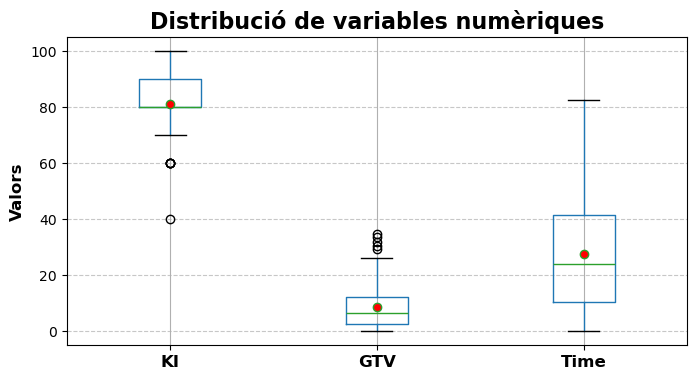

In [11]:
# Box Plot: diagrama en capces.
ax = df_DataBase[['ki', 'gtv', 'time']].boxplot(figsize=(8, 4), patch_artist=False, showmeans=True,meanprops={"marker": "o","markerfacecolor": "red","markersize": 6,})
# Títol
ax.set_title('Distribució de variables numèriques', fontsize=16, weight='bold')

# Etiquetes en el eix  x
ax.set_xticklabels(['KI', 'GTV', 'Time'], fontsize=12, rotation=0, weight='bold')
ax.set_ylabel('Valors', fontsize=12, weight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.show()

## <font color="red"><b>Exercici 7</b></font>
Objectiu d'aquest exercici: Entendre l'informació proporcionada pel BoxPlot
1. Descrigui amb paraules (un paràgraf) per cada variable, a partir del box plot, com es distribueixen les variables.  Què vol dir que una observació estigui a més de 1,5 vegades la desviació estàndard (valor extrem)? Com es veu que la distribució és asimètrica?

## 5. Relacions entre variables
1. **Correlació entre columnes numèriques**
Examinem la correlació entre les columnes numèriques per entendre relacions potencials.
2. **Anàlisi de grups per columnes categòriques**
Examinem com varien les variables numèriques segons les categories.



## 5.1. Explicació intuïtiva de la fórmula de la correlació $r_{X,Y}$

La fórmula de la correlació, coneguda com el **coeficient de correlació de Pearson**, mesura la força i la direcció de la relació lineal entre dues variables, $X$ i $Y$. Ara ho desglossem pas a pas:

### 1. Restar a cada punt  la seva mitjana (**desviacions**)
- $(X_i - \bar{X})$: Calcula la diferència entre el valor $X_i$ i la seva mitjana $\bar{X}$. Això indica com de lluny està $X_i$ respecte al "centre" dels valors de $X$.
- $(Y_i - \bar{Y})$: Fa el mateix per $Y$.

Aquest pas  **centra cada variable** respecte a la seva mitjana, eliminant l'efecte de biaix.

### 2. Producte de les desviacions
- El terme $(X_i - \bar{X})(Y_i - \bar{Y})$ és el producte de la desviació de cada entrada por la desviació de la sortida, tots dos respecte a la mitjana:
  - Si $X_i$ i $Y_i$ són alhora més grans o més petits que les seves respectives mitjanes, aquest producte és positiu (relació positiva).
  - Si un valor és més gran i l'altre més petit que la seva mitjana, el producte és negatiu (relació negativa).

Aquest producte indica com varien conjuntament $X$ i $Y$.

### 3. Sumem els  productes de desviacions
- $\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$: Suma aquests productes per obtenir una mesura acumulada de com $X$ i $Y$ estan relacionades.

Si la suma és gran i positiva, hi ha  correlació positiva. Si és gran i negativa, hi ha  correlació negativa.

### 4. Normalització (divisió per la desviació estàndard)
-  **desviació estàndard de $X$**: $\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2}$.
-  **desviació estàndard de $Y$**: $\sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}$.

Dividim la suma acumulada dels productes per aquests valors perquè:
1. Mesura adimensional independent de l'efecte de les **unitats**, per exemple, si $X$ està en $cm^3$ i $Y$ en mesos.
2. El resultat estigui comprès entre $-1$ i $+1$.

### 5. Resultat final
- **$r_{X,Y} > 0$:** Les variables es mouen en la mateixa direcció (correlació positiva).
- **$r_{X,Y} < 0$:** Les variables es mouen en direccions oposades (correlació negativa).
- **$r_{X,Y} = 0$:** No hi ha cap relació lineal entre $X$ i $Y$.

---

### Intuïció general
La fórmula calcula com de sincronitzades estan $X$ i $Y$ en el seu comportament, centrant-se només en la relació **lineal**. Si canviem l'escala o desplacem les variables, el valor de $r_{X,Y}$ no canviarà perquè només mesura **la força relativa de la relació** entre elles.

- Exemple **$r_{X,Y} > 0$**:
<img src="ExempleCorrelacio.png" alt="ExempleCorrelacio" width="600"/> 
- Exemple **$r_{X,Y}  =  0$**:
<img src="ExempleCorrelacioNula.png" alt="Exemple Correlacio Nula" width="600"/> 


## <font color="red"><b>Exercici 8</b></font>

1. Descrigui amb paraules, a partir de la figura superior, els passos que es segueixen en el càlcul de la funció de correlació. Expliqui què pot significar que 
$(X_i - \bar{X})(Y_i - \bar{Y})$ tingui signes alternats i com això pot afectar el valor del coeficient de correlació $r_{X,Y}$.

## 5.2. Definició formal de la Funció de Correlació

El coeficient de correlació entre dues variables $ X $ i $ Y $ és el coeficient de correlació de Pearson $ r $, que es calcula com:

$r_{X,Y} = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$

On:
- $ n $ és el nombre de parells de puntuacions.
- $ X_i $ i $ Y_i $ són els punts de mostra individuals indexats amb $ i $.
- $ \bar{X} $ i $ \bar{Y} $ són les mitjanes de $ X $ i $ Y $, respectivament.

### Funció de Correlació per les variables: 'ki', 'gtv', 'time'.

Les respectives funcions de correlació son:

$\rho_{ki,gtv} = \frac{\sum_{i=1}^{n} (ki_i - \bar{ki})(gtv_i - \bar{gtv})}{\sqrt{\sum_{i=1}^{n} (ki_i - \bar{ki})^2} \sqrt{\sum_{i=1}^{n} (gtv_i - \bar{gtv})^2}}$

$\rho_{ki,time} = \frac{\sum_{i=1}^{n} (ki_i - \bar{ki})(time_i - \bar{time})}{\sqrt{\sum_{i=1}^{n} (ki_i - \bar{ki})^2} \sqrt{\sum_{i=1}^{n} (time_i - \bar{time})^2}}$

$\rho_{gtv,time} = \frac{\sum_{i=1}^{n} (gtv_i - \bar{gtv})(time_i - \bar{time})}{\sqrt{\sum_{i=1}^{n} (gtv_i - \bar{gtv})^2} \sqrt{\sum_{i=1}^{n} (time_i - \bar{time})^2}}$

On:
- $ \rho $ representa el coeficient de correlació de Pearson.
- $ ki_i $, $ gtv_i $ i $ time_i $ són els punts de mostra individuals per les columnes `ki`, `gtv` i `time`, del DataFrame.
- $ \bar{ki} $, $ \bar{gtv} $ i $ \bar{time} $ són les mitjanes de les columnes `ki`, `gtv` i `time`, del DataFrame.

**Nota**: Observar que el coeficient és adimensional.
**Nota**: El codi següent utilitza  una primitiva de la llibreria "Seaborn".

### 5.2.1. Calcularem la matricu de correlació entre variables numériques.

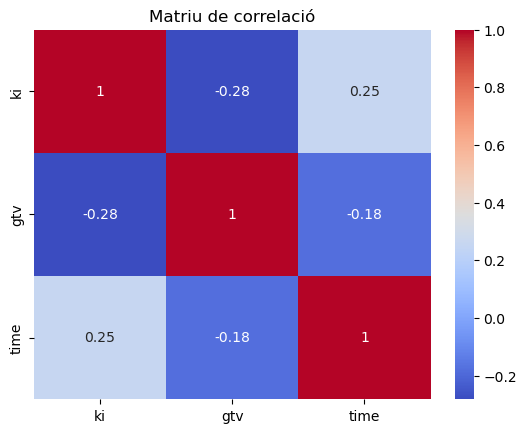

In [13]:
# Matriu de correlació
corr_matrix = df_DataBase[['ki', 'gtv', 'time']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriu de correlació')
plt.show()


## <font color="red"><b>Exercici 9</b></font>
A partir de l'explicació del coeficient de correlació de Pearson, i el significat de les variables.
1. Expliqui que significa que **ki** estigui correlada **positivament** amb el temps de supervivència, i **negativament** amb el tamany del tumor.
2. Expliqui que significa que el tamany del tumor estigui correlat negativament amb el temps de supervivència.
* Recordar:

| Variable | Descripció de variable |
|---|---|
| **sex** | Factor amb nivells "Dona" i "Masculi" |
| **ki** | Índex de Karnofsky. |
| **gtv** | Volum tumoral brut, en centímetres cúbics. |


###  5.2.2. Diagrames "Box Plot" condicionat  per el  'Status': 
#### *ki, gtv, time* vs.  diagnóstic, status

* **Status**: Si el pacient encara està viu al final de l'estudi. **0=Sí, 1=No**.
  

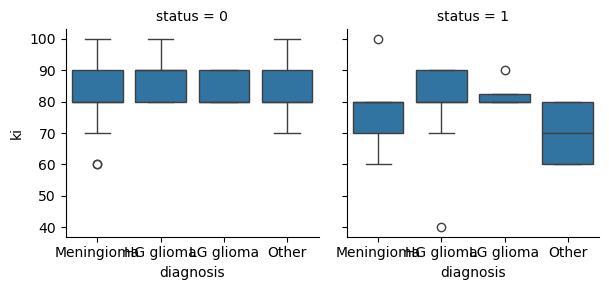

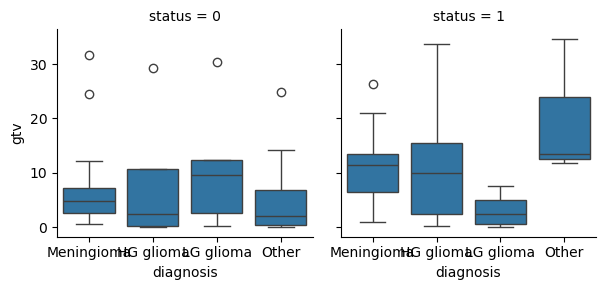

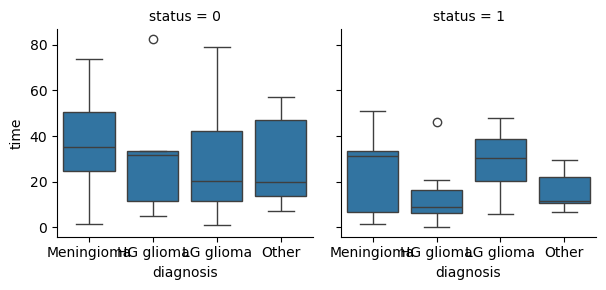

In [14]:
for num_col in ['ki', 'gtv', 'time']:
    g = sns.FacetGrid(df_DataBase, col='status', col_wrap=3, sharey=True)
    cat_order = df_DataBase['diagnosis'].dropna().unique()
    g.map(sns.boxplot, 'diagnosis', num_col, order=cat_order)

## <font color="red"><b>Exercici 10</b></font>

1. Expliqui en un paràgraf, quina utilitat pot tenir representar els diagrames "Box Plot" factoritzat per condició 'Status': 
2. **Per inspecció ràpida** dels blocs, ràpidament, es pot dir si les variables són útils per determinar status, o no?

###  5.2.3. Analisi de la matriu de correlació  completa.

####  Codificació de les variables categòriques

In [34]:
df_DataBase = pd.read_excel('BrainCancer.xlsx')
df_DataBase.drop(columns = ['Unnamed: 0'],inplace = True)

In [35]:
# Codis
sex_mapping = {'Female': 0, 'Male': 1}
diagnosis_mapping = {'Meningioma': 0, 'HG glioma': 1, 'LG glioma': 2, 'Other': 3}
loc_mapping =  {'Supratentorial': 0, 'Infratentorial': 1}
stereo_mapping = {'SRT': 0, 'SRS': 1}

df_mapped = df_DataBase[['sex', 'diagnosis', 'loc', 'stereo']].copy()

df_mapped['sex'] = df_mapped['sex'].map(sex_mapping)
df_mapped['diagnosis'] = df_mapped['diagnosis'].map(diagnosis_mapping)
df_mapped['loc'] = df_mapped['loc'].map(loc_mapping)
df_mapped['stereo'] = df_mapped['stereo'].map(stereo_mapping)

df_DataBase[['sex','diagnosis','loc','stereo']] =  df_mapped[['sex','diagnosis','loc','stereo']]
print(' Base de dades amb les variables codificades')
df_DataBase

 Base de dades amb les variables codificades


,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,0,0,1,90,6.11,1,0,57.64
1,1,1,0,90,19.35,0,1,8.98
2,0,0,1,70,7.95,1,0,26.46
3,0,2,0,80,7.61,0,1,47.80
4,1,1,0,90,5.06,0,1,6.30
...,...,...,...,...,...,...,...,...
83,1,1,0,80,0.16,0,1,20.69
84,1,1,0,80,19.81,0,1,6.39
85,1,0,0,90,2.50,0,0,32.82
86,1,0,0,90,2.02,1,0,42.07


## <font color="red"><b>Exercici avançat</b></font>
1. Expliqui que fà el métode  "map"
   Nota: **map** és útil per estalviar linies de programa.

*Informació per continuar l'exercici*: En aquest cas map a una simple substitució.

In [36]:
# Matriu de correlació
correlation_matrix = df_DataBase.corr()
correlation_matrix.round(3)

,sex,diagnosis,loc,ki,gtv,stereo,status,time
sex,1.000,0.204,-0.016,0.078,0.122,-0.168,0.135,-0.033
diagnosis,0.204,1.000,0.307,-0.063,0.117,-0.080,0.155,-0.177
loc,-0.016,0.307,1.000,0.028,-0.036,0.379,-0.201,0.013
ki,0.078,-0.063,0.028,1.000,-0.282,0.016,-0.257,0.255
gtv,0.122,0.117,-0.036,-0.282,1.000,-0.312,0.234,-0.182
stereo,-0.168,-0.080,0.379,0.016,-0.312,1.000,-0.219,0.164
status,0.135,0.155,-0.201,-0.257,0.234,-0.219,1.000,-0.402
time,-0.033,-0.177,0.013,0.255,-0.182,0.164,-0.402,1.000


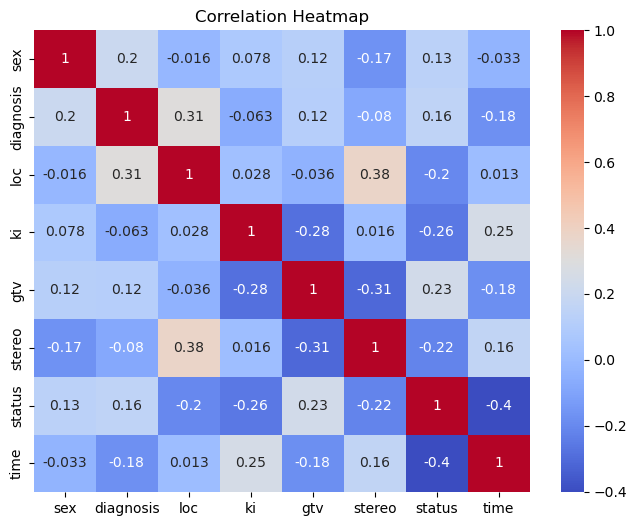

In [37]:
# Heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## <font color="red"><b>Exercici 11</b></font>
**Explicació de la matriu de correlació**
Escriure dos linies per cada pregunta.
1. Identifiqueu les correlacions positives i negatives més fortes (excloent les correlacions d'identitat a la diagonal). Quines són aquestes variables?
2.  Trobeu parells de variables amb correlacions properes a zero. Quines són aquestes variables?
3.  Pot donar una breu explicació, per exemple sex i loc?


###  5.2.4. Correlació de les variables amb el temps de supervivència.

#### **Nota**: Aquest apartat és important, comparar mes endavant amb els coeficients de regressió lineal.

In [38]:
print('\n Valors de la correlació de les variables amb el temps de supervivència. \n\n')
pd.DataFrame(correlation_matrix['time']).round(3).T


 Valors de la correlació de les variables amb el temps de supervivència. 




,sex,diagnosis,loc,ki,gtv,stereo,status,time
time,-0.033,-0.177,0.013,0.255,-0.182,0.164,-0.402,1.0


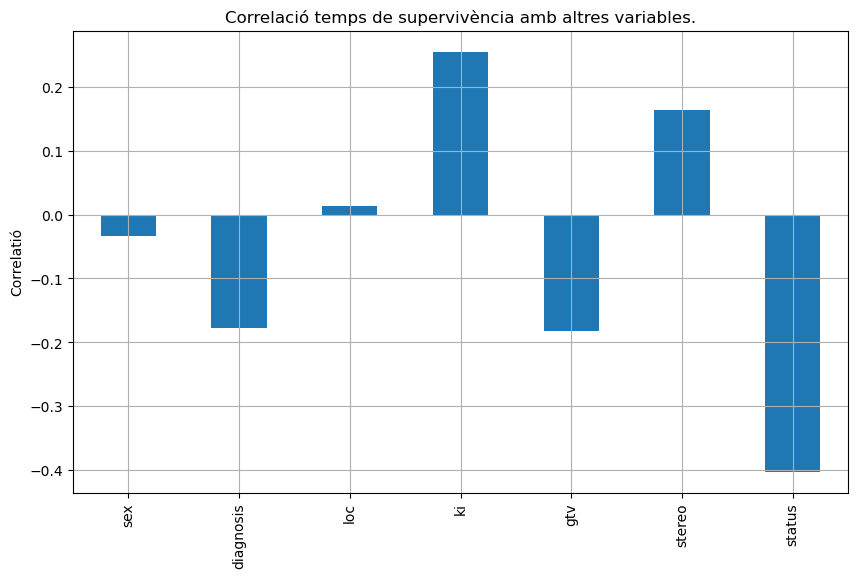

In [21]:
f, ax = plt.subplots(figsize=(10, 6))
ax = correlation_matrix['time'].iloc[:-1].plot.bar()
plt.title('Correlació temps de supervivència amb altres variables.')
ax.xaxis.grid(True)
ax.yaxis.grid(True)
ax.set(ylabel="Correlatió")
plt.show()


## <font color="red"><b>Exercici 12</b></font>
1. Expliqui en un sol paràgraf una explició qualitativa de perquè de la correlació ja sigui positiva o negative de les variables amb el temps de supervivència.

<font color="blue"><b>Regressió no estandard.</b></font>
* **Nota:** Es fa servir molt sovint,  quan s'enten el problema de forma qualitativa i no es vol resoldre el problema de trobar els coeficients amb mínims quadràtics. **(!!!!)**
1. De forma qualitativa i amb coeficients pensats a partir de la figura anterior, proposar valors  $\beta_0 , \beta_1, \beta_2, \ldots, \beta_n $ per cada variable per obtenir un estimador qualitatiu del tipus:

   $$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_n X_n$$

#  6.0. Predicció amb Regressió lineal.

##  6.1. Justificació de la partició entre entrenament i test en Machine Learning

En **Machine Learning**, s'ha de dividir el conjunt de dades en **entrenament** i **test**, per tal de poder saber quin serà el rendiment amb  dades noves. 
Justificació:

1. **Evitar el sobreajustament**:
   - Si el model es valida amb les mateixes dades amb què s'ha entrenat, pot aprendre patrons específics (soroll) en lloc de generalitzar. Això afecta la seva capacitat de treballar amb dades noves.

2. **Estimació de rendiment general**:
   - El conjunt de test proporciona una estimació objectiva de com es comportarà el model amb dades reals, **no vistes durant l'entrenament**.

3. **Validació del model**:
   - Permet comparar diferents models o ajustar hiperparàmetres sense comprometre l'avaluació final amb dades conegudes.

4. **Evitar biaixos en l'avaluació**:
   - Sense una partició clara, el model podria obtenir un rendiment inflat artificialment per haver vist les dades de test durant l'entrenament.

Aquesta metodologia assegura un procés de desenvolupament de models robust i aplicable a situacions reals.


### Explicació del codi:
1. **Definició de les variables X i y:** 
   - Es seleccionen les columnes per a `X` (característiques) excloent `time`.
   - `y` és la variable que volem predir: `time`.

2. **Divisió del conjunt de dades:**
   - S’utilitza `train_test_split` per dividir les dades en conjunts d’entrenament i test. 
   - `test_size=0.2`: El 20% de les dades es reserva per al test.
   - `random_state=42`: Assegura que la divisió sigui reproduïble establint una llavor fixa.

3. **Verificació de les dimensions:**
   - Es mostren les dimensions de cada conjunt (`X_train`, `X_test`, `y_train`, `y_test`) per confirmar que la divisió s’ha fet correctament.


In [23]:
Variables = ["sex", "diagnosis", "loc", "ki", "gtv", "stereo", "status"]
Objectiu = ["time"]
X =  df_DataBase[Variables].copy()
y = df_DataBase[Objectiu].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostra les dimensions dels conjunts resultants
print("X_train shape:", X_train.shape)  # Dimensions del conjunt d'entrenament (característiques)
print("X_test shape:", X_test.shape)    # Dimensions del conjunt de test (característiques)
print("y_train shape:", y_train.shape)  # Dimensions del conjunt d'entrenament (objectiu)
print("y_test shape:", y_test.shape)    # Dimensions del conjunt de test (objectiu)

X_train shape: (70, 7)
X_test shape: (18, 7)
y_train shape: (70, 1)
y_test shape: (18, 1)


## <font color="red"><b>Exercici 13</b></font>
1. Per aclarir idees, expliqui un parell de linies, perquè es fa la divisió train/test.

##  6.2.  Justificació de l'estandardització en Machine Learning

La estandarització, que consisteix a restar la mitjana i dividir per la desviació típica, és una pràctica important en Machine Learning per les raons següents:

1. **Normalització, fer independent de l'escala: (km, cm, kg, gm, etc.)**
   * Les característiques amb escales diferents poden influir de manera desigual en el model. L'estandardització assegura que totes les característiques tinguin una escala comparable.

2. **Evitar biaixos induïts per escales:**
   * L'ús de característiques amb escales diferents pot introduir biaixos en el rendiment i la interpretació del model.

La estandarització s'aplica utilitzant la següent fórmula:

$$z = \frac{x - \mu}{\sigma}$$

On:
* `x` és el valor de la variable.
* `μ` és la mitjana de la variable al conjunt d'entrenament.
* `σ` és la desviació típica de la variable al conjunt d'entrenament.
* `z` és el valor estandarditzat.

**Nota:** És important calcular `μ` i `σ` només amb el conjunt d'entrenament, i després utilitzar aquests valors per transformar tant el conjunt d'entrenament com el de test per evitar *data leakage*.

In [24]:
scaler = StandardScaler()
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
X_scaled = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)


In [25]:
print("Valors abans d'estandaritzar")
pd.DataFrame(X_train,columns = X.columns).describe().round(1).iloc[1:]

Valors abans d'estandaritzar


,sex,diagnosis,loc,ki,gtv,stereo,status
mean,0.5,0.9,0.2,81.0,8.6,0.2,0.4
std,0.5,1.1,0.4,10.9,8.5,0.4,0.5
min,0.0,0.0,0.0,40.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,80.0,2.5,0.0,0.0
50%,0.0,1.0,0.0,80.0,6.6,0.0,0.0
75%,1.0,1.0,0.0,90.0,12.0,0.0,1.0
max,1.0,3.0,1.0,100.0,33.7,1.0,1.0


In [26]:
print("Valors després d'estandaritzar")
pd.DataFrame(X_scaled,columns = X.columns).describe().round(1).iloc[1:]

Valors després d'estandaritzar


,sex,diagnosis,loc,ki,gtv,stereo,status
mean,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-0.9,-0.8,-0.5,-3.8,-1.0,-0.5,-0.8
25%,-0.9,-0.8,-0.5,-0.1,-0.7,-0.5,-0.8
50%,-0.9,0.1,-0.5,-0.1,-0.2,-0.5,-0.8
75%,1.1,0.1,-0.5,0.8,0.4,-0.5,1.2
max,1.1,2.0,2.2,1.8,3.0,2.0,1.2


## <font color="red"><b>Exercici 14</b></font>
1. Per aclarir idees, expliqui un parell de linies, les diferències entre estandaritzar i no estandaritzar en quan a valor mig, desviació estandard, i rang interquantil.

##  6.3.  Calcul de la funció de regressió per estimar el temps de supervivència.

In [27]:
# Inicialitzem i entrenem el model

model = LinearRegression()
model.fit(X_scaled, y_train)

# Mostrem els coeficients
Variables = ["sex", "diagnosis", "loc", "ki", "gtv", "stereo", "status"]
Objectiu = ["time"]
df_coeficients = pd.DataFrame(model.coef_,  columns=Variables)
# Fem prediccions sobre el conjunt de test
y_pred = model.predict(X_scaled_test)

##  6.3.1  Veurem si la predicció és bóna.

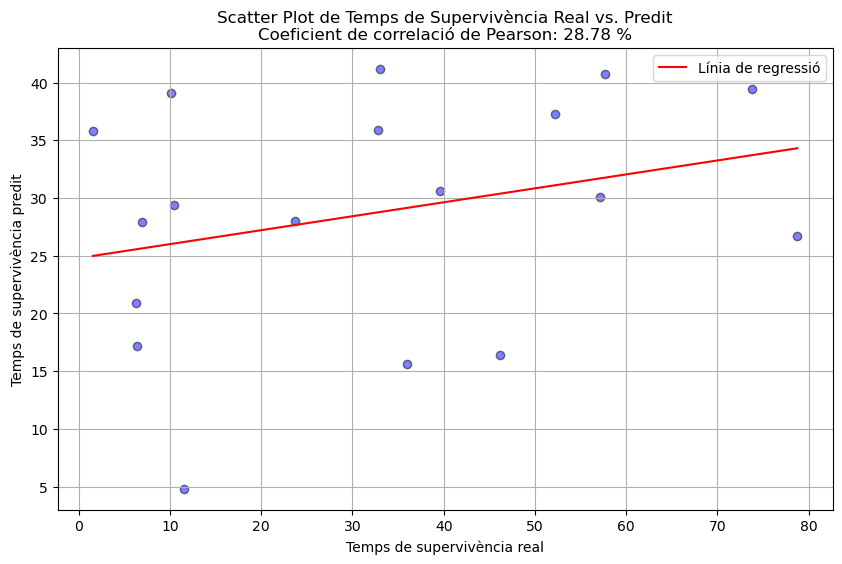

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Assuming y_test and y_pred are already defined
plt.figure(figsize=(10, 6))
plt.scatter(y_test.values.ravel(), y_pred.ravel(), alpha=0.5, color='blue', edgecolor='black')

plt.xlabel('Temps de supervivència real')
plt.ylabel('Temps de supervivència predit')

# Càlcul del Coeficient de correlació de Pearson
pearson_corr = np.corrcoef(y_test.values.ravel(), y_pred.ravel())[0, 1]

plt.title(f'Scatter Plot de Temps de Supervivència Real vs. Predit\nCoeficient de correlació de Pearson: {pearson_corr*100:.2f} %')

plt.grid(True)

X = y_test.values
y = y_pred

model = LinearRegression().fit(X, y)
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred_line = model.predict(x_range)

# Linea de regressió
plt.plot(x_range, y_pred_line, color='red', label='Línia de regressió')

plt.legend()

plt.show()

## <font color="red"><b>Exercici 15</b></font>
1. Expliqui un parell de linies, la figura anterior, relacioni el coeficient de correlació de Pearson amb la qualitat obtinguda.

##  6.3.2  Analitzarem els coeficients de predicció lineal,

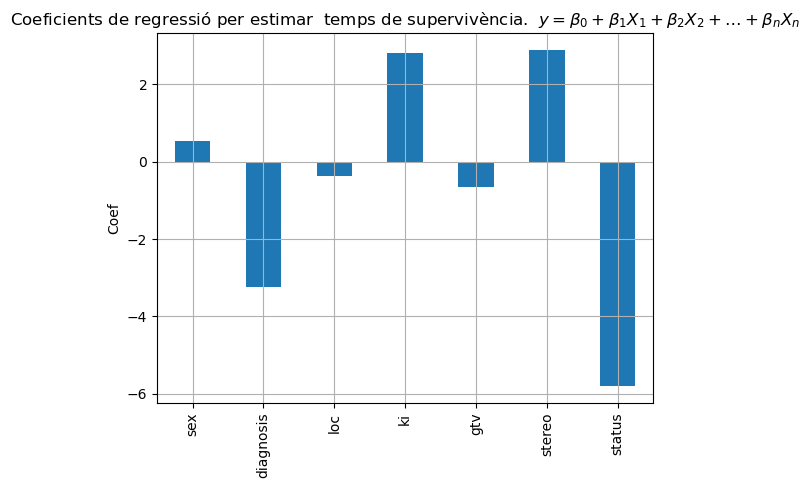

In [29]:

ax = df_coeficients.T.plot.bar(legend = False)
plt.title(r'Coeficients de regressió per estimar  temps de supervivència.  $ y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_n X_n $')
ax.xaxis.grid(True)
ax.yaxis.grid(True)
ax.set(ylabel="Coef")
plt.show()

####  Comparació Coeficients de regressió amb  els de Correlacio

Comparació Coeficients de regressió amab  Correlacio


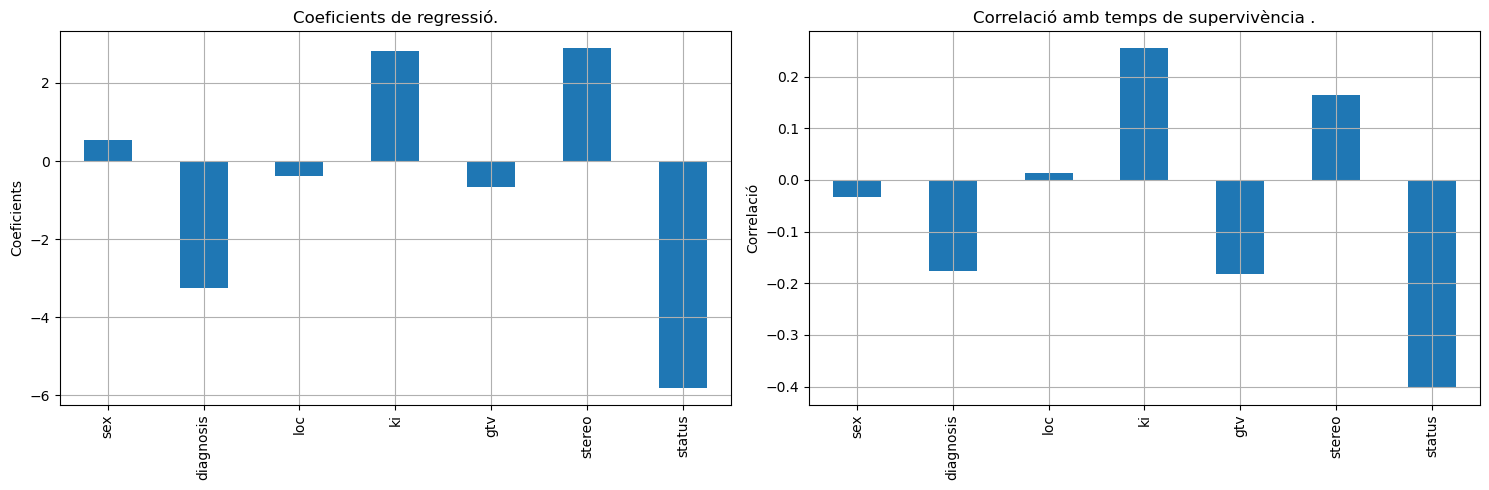

In [ ]:
print('Comparació Coeficients de regressió amb  els de Correlacio')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

df_coeficients.T.plot.bar(ax=ax1, legend=False)
ax1.set_title('Coeficients de regressió.')
ax1.xaxis.grid(True)
ax1.yaxis.grid(True)
ax1.set_ylabel("Coeficients")


correlation_matrix['time'].iloc[:-1].plot.bar(ax=ax2)
ax2.set_title('Correlació amb temps de supervivència .')
ax2.xaxis.grid(True)
ax2.yaxis.grid(True)
ax2.set_ylabel("Correlació")

plt.tight_layout()
plt.show()



## <font color="red"><b>Exercici 16</b></font>
**Important**
1. Expliqui en un paràgraf la semblança entre els coeficients i els valors del predictor lineal. Comenti en coicidència en signe, i coincidència en valors relatius.

##  6.3.3  Comparació en mes detall

In [31]:
CompCoef_Corr = pd.concat([df_coeficients.T,correlation_matrix['time']],axis = 1).drop('time',axis = 0)
CompCoef_Corr.columns = ['Coef', 'Corr']
CompCoef_Corr

,Coef,Corr
sex,0.540031,-0.032950
diagnosis,-3.236392,-0.176827
loc,-0.378801,0.012888
ki,2.816230,0.254931
gtv,-0.650821,-0.181520
stereo,2.886630,0.164199
status,-5.800285,-0.402224


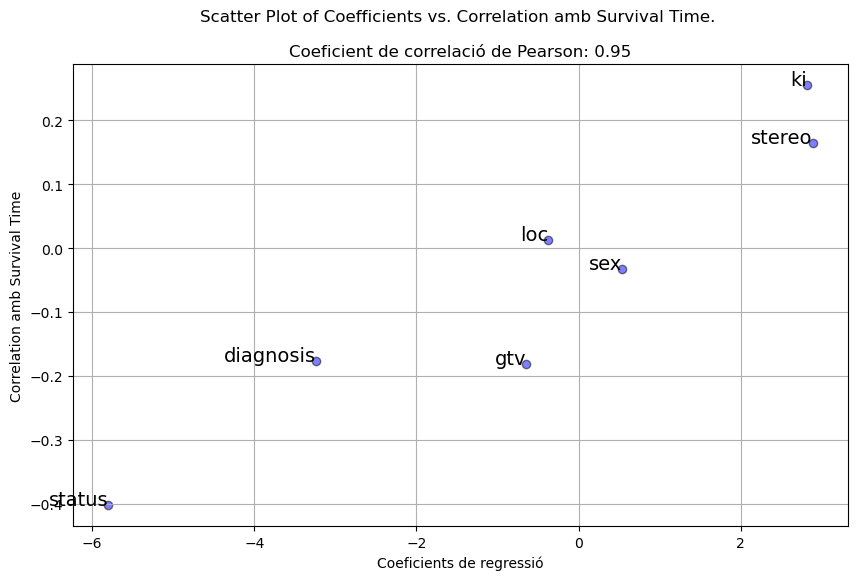

Coeficient de correlació de Pearson: 94.76 % 


In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(CompCoef_Corr['Coef'], CompCoef_Corr['Corr'], alpha=0.5, color='blue', edgecolor='black')


plt.xlabel('Coeficients de regressió')
plt.ylabel('Correlation amb Survival Time')
pearson_corr = np.corrcoef(CompCoef_Corr['Coef'], CompCoef_Corr['Corr'])[0, 1]

plt.title(f'Scatter Plot of Coefficients vs. Correlation amb Survival Time. \n \nCoeficient de correlació de Pearson: {pearson_corr:.2f}')

plt.grid(True)

# Nom de cada variable
for i, txt in enumerate(CompCoef_Corr.index):
    plt.annotate(txt, (CompCoef_Corr['Coef'].iloc[i], CompCoef_Corr['Corr'].iloc[i]), fontsize=14, ha='right')

plt.show()

print(f'Coeficient de correlació de Pearson: {pearson_corr*100:.2f} % ')

## <font color="red"><b>Exercici 17</b></font>
1. Expliqui en un paràgraf com s'interpreta la figura anterior i el significat del coeficient de Pearson, en el sentit de preseravar l'ordre.
2. Justifiqui en una línea, a partir de la figura anterior, el us de la regressió no estandard.

## <font color="Blue"><b>Informe Final i Recomanacions</b></font>
1. Informe on es relaciona la informació obtinguda amb l'estudi fet amb l'EDA amb els resultats obtinguts pel mètode de machine learning.

2. Recomanacions per millorar el sistema i implementar-lo.


# Apendix 1
### Mètode d'Estimació: Mínims Quadrats (Explicació Detallada)

#### Per Què Necessitem Mínims Quadrats?

Quan construïm un model de regressió lineal, el nostre objectiu principal és trobar la millor línia que s'ajusta a les nostres dades. "Millor" significa minimitzar la diferència entre els valors predits pel nostre model i els valors reals observats.

#### La Lògica Darrera els Mínims Quadrats

Imagina que estem dibuixant una línia que passa a través d'un conjunt de punts. La línia mai passarà perfectament per tots els punts. Les diferències entre els punts i la línia s'anomenen "residus" o "errors".

$e_i = y_i - \hat{y}_i$

On:
- $e_i$ és l'error per a cada punt
- $y_i$ és el valor real
- $\hat{y}_i$ és el valor predit pel model

#### Per Què Elevar al Quadrat?

Quan calculem errors, podríem simplement sumar-los. Però hi ha un problema: els errors positius i negatius es cancel·larien entre si. Per exemple:
- Un punt 2 unitats per sobre de la línia
- Un altre punt 2 unitats per sota de la línia

Si sumem aquests errors, obtindríem 0, quan clarament hi ha desviació!

Per resoldre això, elevem els errors al quadrat:
1. Sempre seran positius
2. Els errors grans tindran més pes
3. Penalitza més les prediccions lluny de la línia real

#### La Fórmula Matemàtica

La funció de cost de mínims quadrats es defineix com:

$\min_{\beta} \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1x_{1i} + \beta_2x_{2i} + ... + \beta_nx_{ni}))^2$

Interpretem cada part:
- $\sum$ significa "suma de tots els punts"
- $(y_i - \text{predicció})^2$ calcula l'error quadràtic de cada punt
- Busquem minimitzar aquesta suma total d'errors

#### Mètodes de Resolució

Hi ha diverses tècniques per minimitzar aquest error:
1. **Solució Analítica**: 
   - Derivades
   - Àlgebra lineal
   - Fórmula matemàtica tancada

2. **Mètodes Iteratius**:
   - Descens de Gradient
   - Optimitza els coeficients pas a pas
   - Especialment útil per conjunts de dades grans

#### Exemple Intuïtiu

Pensem en un agricultors que vol predir la collita:
- Variables: Pluja, temperatura, fertilitzant
- Mínims quadrats trobaran els millors pesos per cada variable
- L'objectiu: minimitzar la diferència entre collites predites i reals

#### Limitacions

El mètode de mínims quadrats assumeix:
- Relació linear entre variables
- Errors distribuïts normalment
- No hi ha outliers extrems

### Conclusió

Mínims quadrats és una eina matemàtica elegant que ens permet construir models predictius ajustant-nos el màxim possible a les dades reals, minimitzant sistemàticament els nostres errors de predicció.